##### Business Problem Statement

IronPulse Manufacturing operates CNC milling machines 24/7. Unexpected machine failures stop production, causing expensive downtime, repair costs, delayed orders, and revenue loss.

The company wants an AI/Machine Learning model that can predict machine failures before they happen so maintenance can be scheduled in advance instead of after a breakdown

##### Objective 

Your goal is to analyze machine sensor data and build a machine learning model that predicts future machine failures.

There are two options.

Option A (Recommended)

Predict only:
Will the machine fail?
Yes (1)
No (0)

This is a Binary Classification problem.

Target Variable:-
Machine failure

Option B (Advanced)
Predict Which failure type will happen?

Possible classes are

Tool Wear Failure (TWF)
Heat Dissipation Failure (HDF)
Power Failure (PWF)
Overstrain Failure (OSF)
Random Failure (RNF)

This is a Multi-class/Multi-label Classification problem.


##### Data Dictionary

* UDI :- 
Unique ID assigned to each machine record

* Product ID :-
Product identifier. The first letter also indicates product type 

* Type :- 
Product quality type: L = Low, M = Medium, H = High

* Air temperature [K] :- Ambient (surrounding) air temperature measured in Kelvin (K).

* Process temperature[K] :- Temperature inside the machine during operation, measured in Kelvin (K).

* Rotational speed[rpm] :- Speed of the spindle or rotating component in revolutions per minute (RPM).

* Torque [Nm] :- Rotational force produced by the machine, measured in Newton-meters (Nm)

* Tool wear[min] :- Total operating time of the cutting tool in minutes.

* 

Importing Library

In [1]:
a = [10,20,30]

In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 


In [4]:
import pandas as pd

df = pd.read_csv("../data/ai4i2020.csv")

In [5]:
df.columns

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='object')

In [4]:
df.shape 

(10000, 14)

* There are 10000 rows and 14 columns

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

* 12 numeric cols :- 3 (float) and 9 (integer)
* 2 categorical cols
* no missing values

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
UDI,10000.0,5000.50000,2886.895680,1.0,2500.75,5000.5,7500.25,10000.0
Air temperature [K],10000.0,300.00493,2.000259,295.3,298.30,300.1,301.50,304.5
Process temperature [K],10000.0,310.00556,1.483734,305.7,308.80,310.1,311.10,313.8
Rotational speed [rpm],10000.0,1538.77610,179.284096,1168.0,1423.00,1503.0,1612.00,2886.0
Torque [Nm],10000.0,39.98691,9.968934,3.8,33.20,40.1,46.80,76.6
Tool wear [min],10000.0,107.95100,63.654147,0.0,53.00,108.0,162.00,253.0
Machine failure,10000.0,0.03390,0.180981,0.0,0.00,0.0,0.00,1.0
TWF,10000.0,0.00460,0.067671,0.0,0.00,0.0,0.00,1.0
HDF,10000.0,0.01150,0.106625,0.0,0.00,0.0,0.00,1.0
PWF,10000.0,0.00950,0.097009,0.0,0.00,0.0,0.00,1.0


##### Observations 

* Air temperature ranges narrowly between 295.3k and 304.5 K

* Process temperature ranges between 305.7k and 313.8 k 

* Torque ranges from 3.8 Nm to 76.6 Nm with a mean of 39.99 Nm and a median of 40.1 Nm. Since the mean and median are very close, the distribution may be approximately symmetric. However, this should be confirmed using a histogram or boxplot.

* Tool wear ranges from 0 to 253 minutes with a mean of 107.95 minutes and a median of 108 minutes. Since the mean and median are nearly equal, the distribution may be approximately symmetric. The actual distribution should be verified using a histogram.

* Rotational Speed -
 
   Rotational speed ranges from 1168 rpm to 2886 rpm with a mean of 1538.78 rpm and a median of 1503 rpm. Since the mean is slightly greater than the median, the distribution may exhibit slight positive (right) skewness. This should be confirmed using a histogram or boxplot.

* Machine failure 

only 3.39% of observations are labeled as machine failures the remaining 96.6% are normal operations

This is highly imbalanced data more focus should be on minority class 

accuracy alone would be misleading evalution metric .Metric like precision,Recall,f1-score and resampling techniques like (smote,class weighting) should be considered before modeling

* failure Types

Among the individual failure modes, Heat Dissipation Failure (HDF) is the most common (1.15%), followed by Overstrain Failure (OSF, 0.98%) and Power Failure (PWF, 0.95%). Tool Wear Failure (TWF, 0.46%) is less frequent, while Random Failure (RNF, 0.19%) is the rarest failure type

In [6]:
df.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

* no duplicates value

Stage 1: Exploratory Data Analysis

Part A : Univarite Analysis

Numeric Features

In [8]:
num_cols = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
]

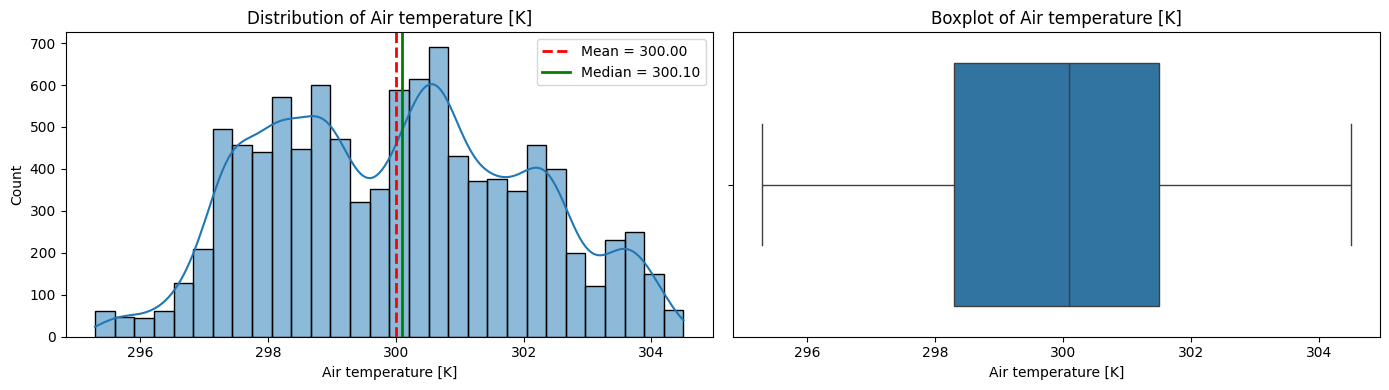

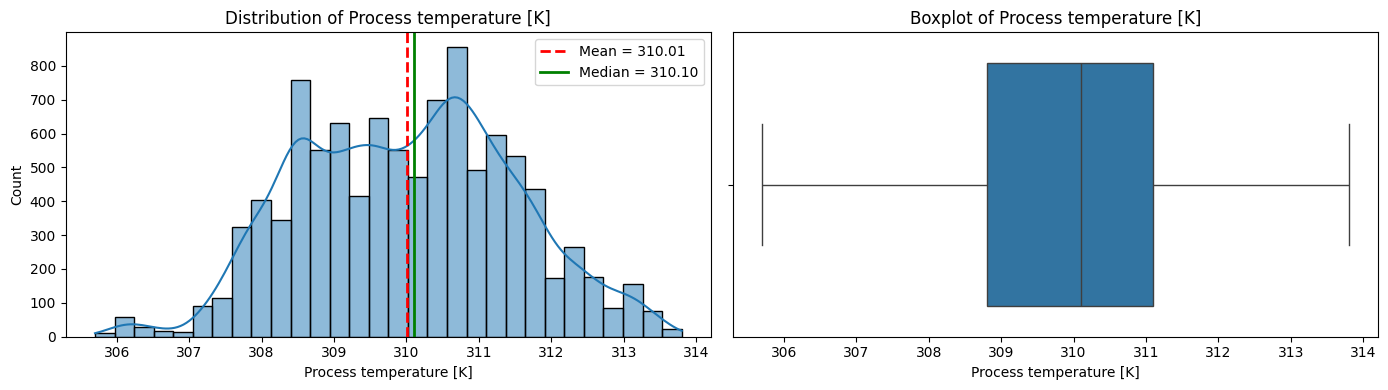

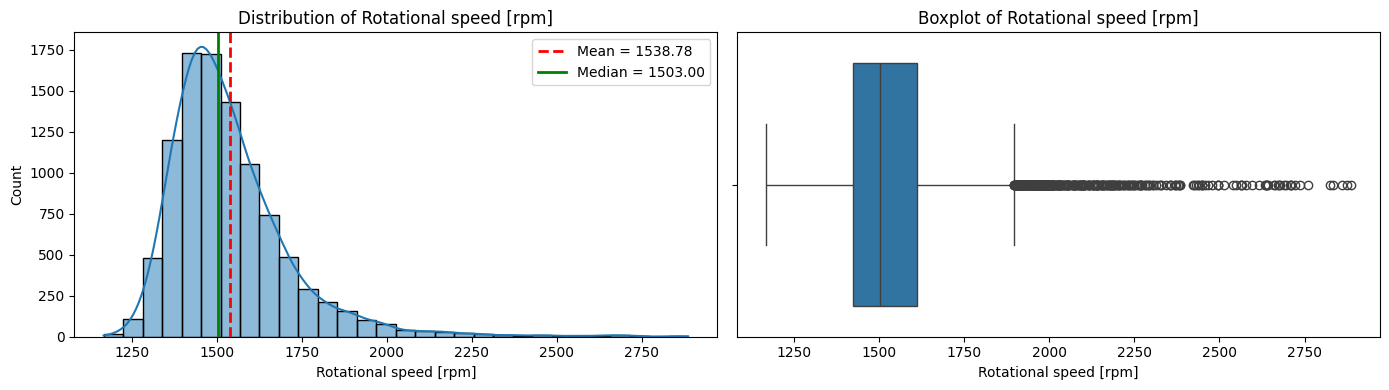

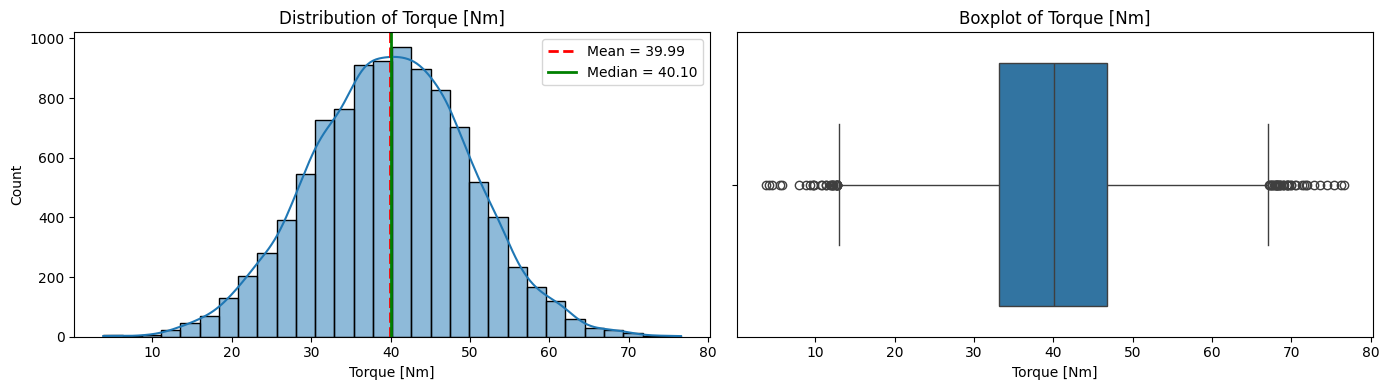

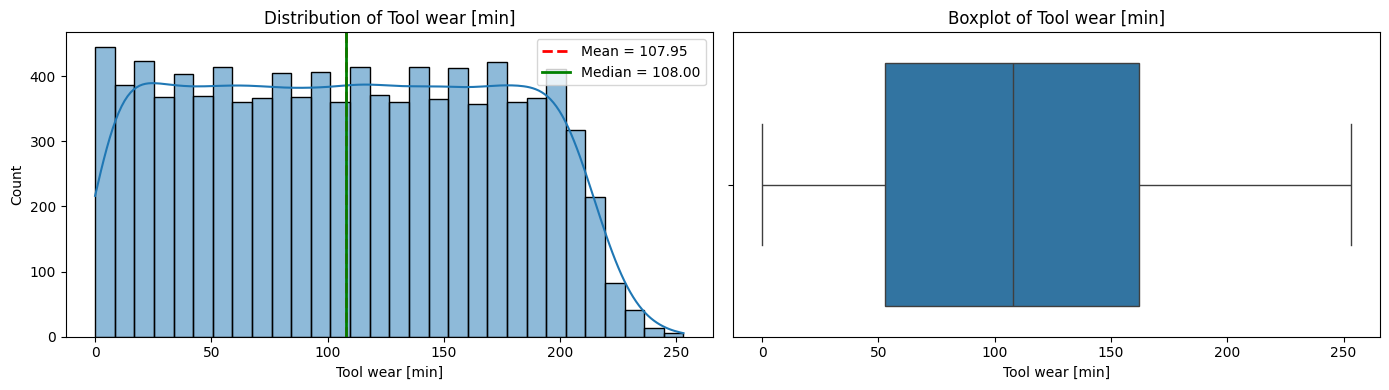

In [10]:
for col in num_cols:

    plt.figure(figsize=(14,4))

    # Histogram + KDE
    plt.subplot(1,2,1)

    sns.histplot(df[col], kde=True, bins=30)

    plt.axvline(
        df[col].mean(),
        color='red',
        linestyle='--',
        linewidth=2,
        label=f"Mean = {df[col].mean():.2f}"
    )

    plt.axvline(
        df[col].median(),
        color='green',
        linestyle='-',
        linewidth=2,
        label=f"Median = {df[col].median():.2f}"
    )

    plt.title(f"Distribution of {col}")
    plt.legend()

    # Boxplot
    plt.subplot(1,2,2)

    sns.boxplot(x=df[col])

    plt.title(f"Boxplot of {col}")

    plt.tight_layout()
    plt.show()

In [ ]:
cat_cols = ['Type']
for col in cat_cols:
    sns.countplot(data=df, x=col)
    plt.title(f"Count Plot of {col}")
    plt.show()

    print(df[col].value_counts())
sns.countplot(data=df, x='Machine failure')
plt.show()
df['Machine failure'].value_counts(normalize=True) * 100

##### Observation

   * Air temperature and process temperature are approximately normally distributed with low variability and no significant outliers

   * Rotational speed exhibits Right (positive) skewness and contains several high-value outliers

   * Torque follows an approximately normal distribution with a few extreme observations

   * Tool wear is approximately uniformly distributed over most of its range and does not exhibit significant outliers

   * None of the observed outliers appear to be obvious data-entry errors; they are likely valid operational measurements and will be retained for further analysis.

##### Outlier Treatment

Outliers were identified in Rotational Speed and Torque using boxplots. However, these values were not removed or capped, as they are likely to represent genuine machine operating conditions rather than measurement or data-entry errors. In predictive maintenance, extreme sensor readings often precede machine failures and therefore contain valuable predictive information. Removing or capping these observations could reduce the model's ability to detect failure patterns

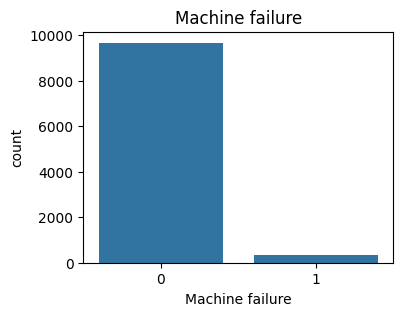

Machine failure
0    9661
1     339
Name: count, dtype: int64


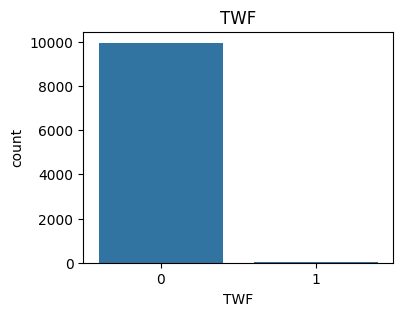

TWF
0    9954
1      46
Name: count, dtype: int64


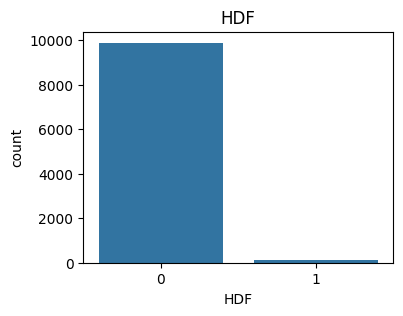

HDF
0    9885
1     115
Name: count, dtype: int64


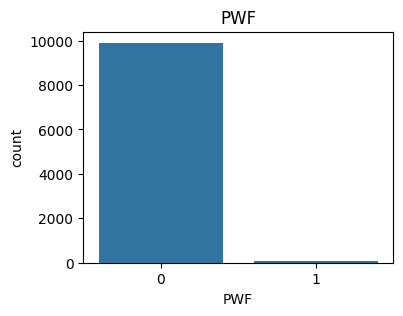

PWF
0    9905
1      95
Name: count, dtype: int64


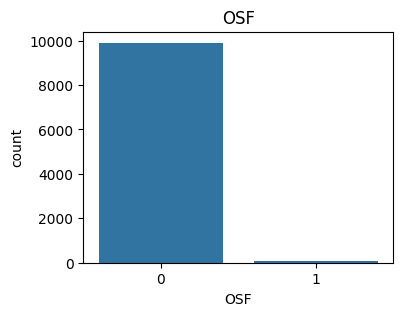

OSF
0    9902
1      98
Name: count, dtype: int64


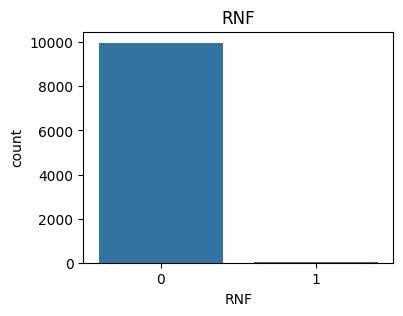

RNF
0    9981
1      19
Name: count, dtype: int64


In [11]:
failure_cols = [
    'Machine failure',
    'TWF',
    'HDF',
    'PWF',
    'OSF',
    'RNF'
]

for col in failure_cols:
    plt.figure(figsize=(4,3))
    sns.countplot(data=df, x=col)
    plt.title(col)
    plt.show()

    print(df[col].value_counts())

Heat Dissipation Failure (HDF) is the most common failure mode, followed by Overstrain Failure (OSF) and Power Failure (PWF), while Tool Wear Failure (TWF) is relatively rare and Random Failure (RNF) is the least frequent failure type

Bivariate Analysis

Step 1: Distribution Split by Machine Failure



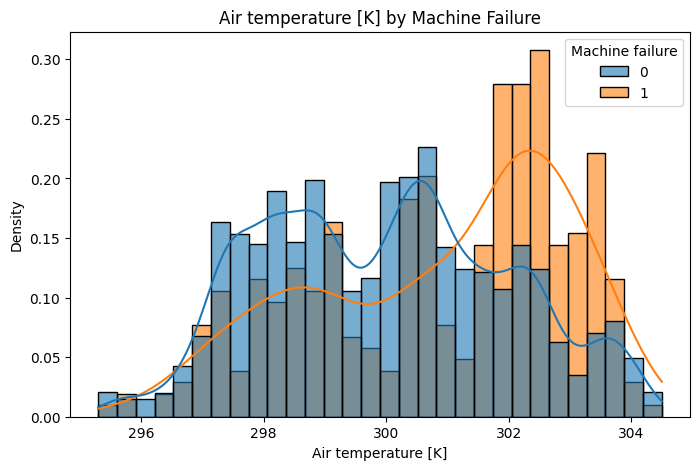

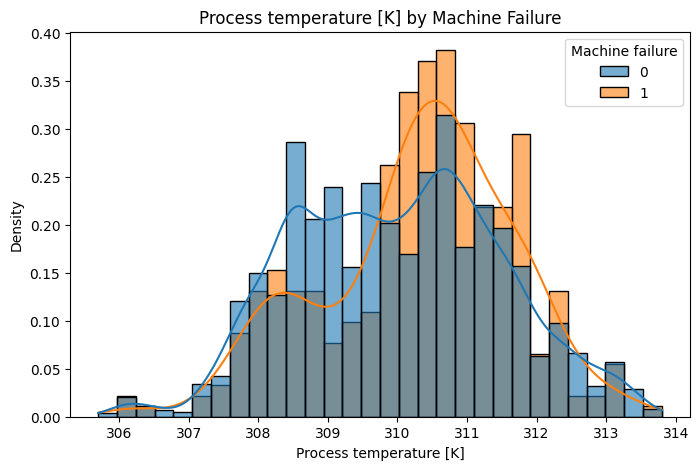

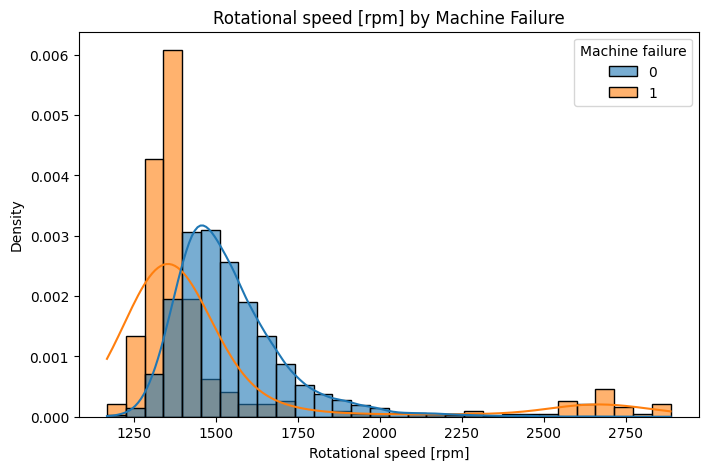

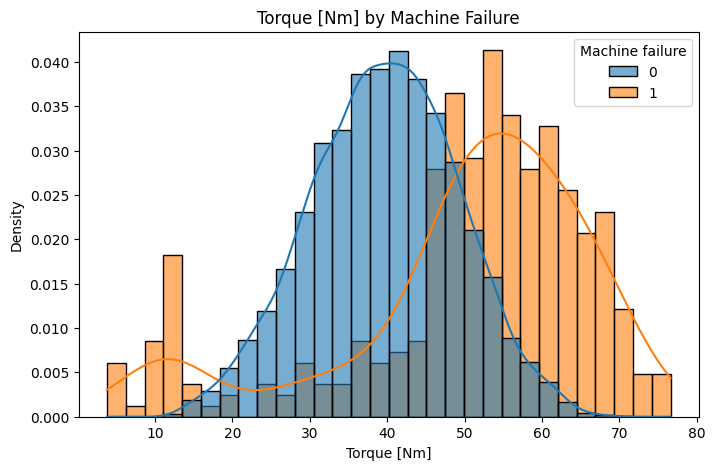

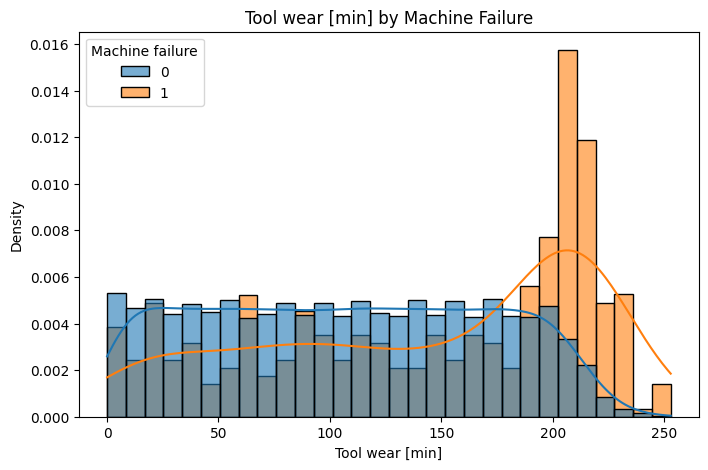

In [ ]:

sensor_cols = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
]

for col in sensor_cols:

    plt.figure(figsize=(8,5))

    sns.histplot(
        data=df,
        x=col,
        hue='Machine failure',
        kde=True,
        bins=30,
        stat='density',
        common_norm=False,
        alpha=0.6
    )

    plt.title(f'{col} by Machine Failure')
    plt.show()


* Torque and Tool Wear are individually strong predictors.

* Air and Process Temperature individually are weak predictors, but their combination (especially the temperature difference) may better explain failures.

*  Rotational speed shows failure cases at both low and very high RPM values, indicating that machines operating outside the normal speed range are more susceptible to failure.

* This suggests that abnormal rotational speeds, particularly when combined with high mechanical load (torque), may contribute to machine failure.

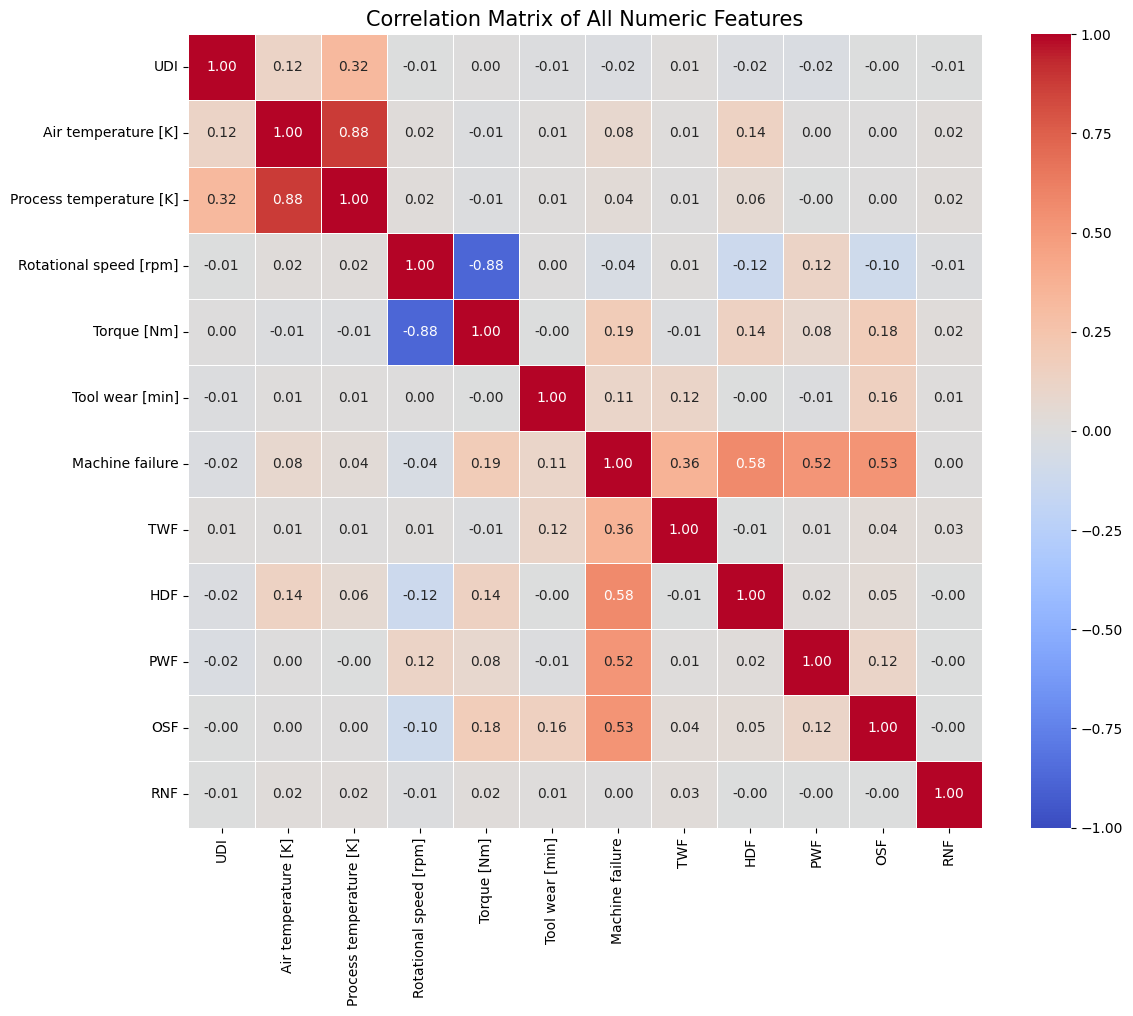

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,10))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,          # Show correlation values
    fmt=".2f",           # Display 2 decimal places
    cmap="coolwarm",     # Blue = Negative, Red = Positive
    linewidths=0.5,
    square=True,
    vmin=-1,
    vmax=1
)

plt.title("Correlation Matrix of All Numeric Features", fontsize=15)
plt.tight_layout()
plt.show()

##### Correlation Analysis

* Air Temperature and Process Temperature exhibit a strong positive correlation (r = 0.88), indicating that higher ambient temperatures are associated with higher process temperatures.

* Rotational Speed and Torque show a strong negative correlation (r = -0.88), meaning that machines operating at lower RPM generally experience higher torque.

* Air Temperature and Torque (r = -0.01), Process Temperature and Torque (r = -0.01), Tool Wear and Rotational Speed (r = 0.00), and Tool Wear and Torque (r ≈ 0.00) show little to no linear correlation, suggesting these variables are largely independent.

* Machine Failure has weak positive correlations with Torque (r = 0.19) and Tool Wear (r = 0.11), indicating that these features alone are not sufficient to explain failures but may become more informative when combined with other variables.

* The failure mode indicators (HDF, PWF, OSF, and TWF) show moderate positive correlations with Machine Failure because they represent specific types of machine failures.

1.Air Temperature vs Process Temperature

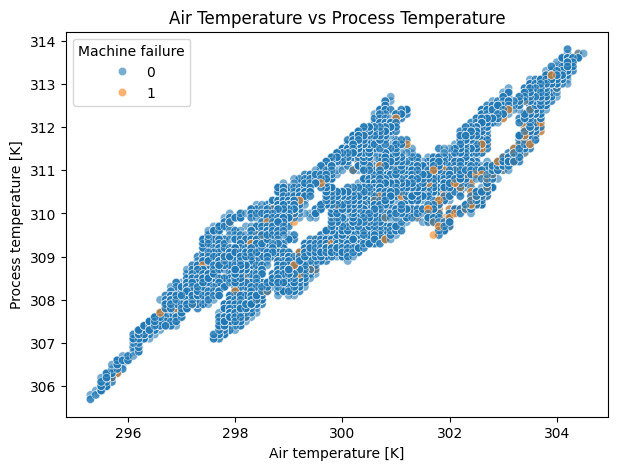

In [8]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df,
    x='Air temperature [K]',
    y='Process temperature [K]',
    hue='Machine failure',
    alpha=0.6
)

plt.title("Air Temperature vs Process Temperature")
plt.show()

* Machine failures are observed more frequently at higher air and process temperatures, although there is considerable overlap with normal operations.

2. Rotational Speed vs Torque

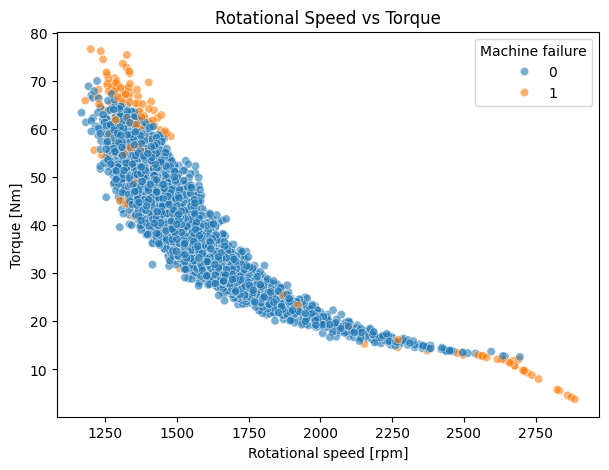

In [9]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df,
    x='Rotational speed [rpm]',
    y='Torque [Nm]',
    hue='Machine failure',
    alpha=0.6
)

plt.title("Rotational Speed vs Torque")
plt.show()

* Most machine failures occur under low RPM with high torque, while a few failures are also observed at very high RPM with low torque, indicating that extreme operating conditions are associated with failures.

Physical Sanity Check


    

HDF    115
OSF     98
PWF     95
TWF     46
RNF     19
dtype: int64


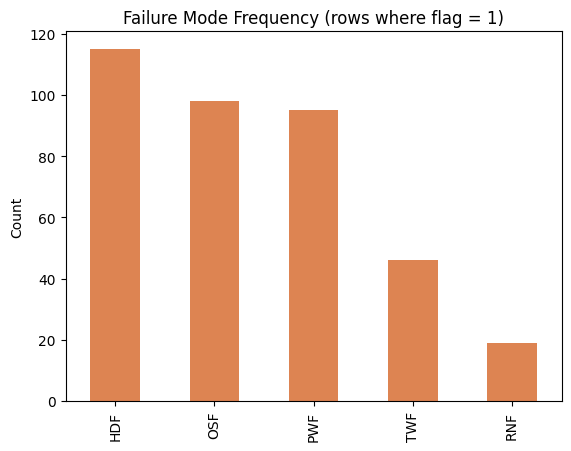

In [10]:
# Individual failure-mode flags
modes = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
mode_counts = df[modes].sum().sort_values(ascending=False)
print(mode_counts)

fig, ax = plt.subplots()
mode_counts.plot(kind='bar', ax=ax, color='#DD8452')
ax.set_title('Failure Mode Frequency (rows where flag = 1)')
ax.set_ylabel('Count')
plt.show()


In [12]:
# -------------------------------
# Physics Sanity Check
# -------------------------------

# Failure mode columns
modes = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']

# Number of failure modes in each observation
df['mode_sum'] = df[modes].sum(axis=1)

# Cross-tabulation of each failure mode with Machine Failure
for col in modes:
    print(f"\n{'='*15} {col} {'='*15}")
    print(pd.crosstab(df[col], df['Machine failure']))

# Check for inconsistent labels
no_mode_but_failed = ((df['Machine failure'] == 1) & (df['mode_sum'] == 0)).sum()

mode_but_no_failure = ((df['Machine failure'] == 0) & (df['mode_sum'] > 0)).sum()

multi_mode = (df['mode_sum'] > 1).sum()

print("\n" + "="*50)
print("Physics Sanity Check Summary")
print("="*50)

print(f"Rows where Machine failure = 1 but NO failure mode is present : {no_mode_but_failed}")
print(f"Rows where Machine failure = 0 but a failure mode is present : {mode_but_no_failure}")
print(f"Rows with multiple failure modes occurring simultaneously     : {multi_mode}")

# Display rows with multiple failure modes
print("\nRows having more than one failure mode:\n")

display(
    df.loc[df['mode_sum'] > 1,
           ['Machine failure'] + modes]
)


=============== TWF ===============
Machine failure     0    1
TWF                       
0                9661  293
1                   0   46

=============== HDF ===============
Machine failure     0    1
HDF                       
0                9661  224
1                   0  115

=============== PWF ===============
Machine failure     0    1
PWF                       
0                9661  244
1                   0   95

=============== OSF ===============
Machine failure     0    1
OSF                       
0                9661  241
1                   0   98

=============== RNF ===============
Machine failure     0    1
RNF                       
0                9643  338
1                  18    1

Physics Sanity Check Summary
Rows where Machine failure = 1 but NO failure mode is present : 9
Rows where Machine failure = 0 but a failure mode is present : 18
Rows with multiple failure modes occurring simultaneously     : 24

Rows having more than one failure mode:



,Machine failure,TWF,HDF,PWF,OSF,RNF
69,1,0,0,1,1,0
1324,1,0,0,1,1,0
1496,1,0,0,1,1,0
3611,1,1,0,0,0,1
3854,1,0,0,1,1,0
3943,1,0,0,1,1,0
4254,1,0,1,1,0,0
4342,1,0,1,1,0,0
4370,1,0,1,0,1,0
4383,1,0,1,0,1,0


Which combination of failure modes occurs most often?

In [16]:
modes = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']

# Keep only rows with multiple failure modes
multi_mode_df = df[df['mode_sum'] > 1]

# Create a column showing the combination of failure modes
multi_mode_df['Failure_Combination'] = multi_mode_df[modes].apply(
    lambda row: ', '.join(row.index[row == 1]),
    axis=1
)

# Count each combination
combination_counts = multi_mode_df['Failure_Combination'].value_counts()

print(combination_counts)

Failure_Combination
PWF, OSF         11
HDF, OSF          6
HDF, PWF          3
TWF, OSF          2
TWF, RNF          1
TWF, PWF, OSF     1
Name: count, dtype: int64


C:\Users\hp\AppData\Local\Temp\ipykernel_18840\4020409532.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  multi_mode_df['Failure_Combination'] = multi_mode_df[modes].apply(


##### Observation

##### Observations

* Out of 339 machine failure cases, 315 failures were caused by a single failure mode, while only 24 failures resulted from multiple failure modes occurring simultaneously.

* Among the single failure modes, Heat Dissipation Failure (HDF) is the most frequent cause of machine failure.

* Among the multiple failure mode combinations, Power Failure (PWF) and Overstrain Failure (OSF) occur together most frequently (11 cases), followed by HDF + OSF (6 cases) and HDF + PWF (3 cases).

* Very few machines experienced three simultaneous failure modes. Only one observation showed the combination of TWF + PWF + OSF.

* Overall, most machine failures are caused by a single failure mode, whereas multiple simultaneous failure modes are relatively uncommon.


##### Hypothesis 1: Temperature Interaction

Machines operating under high air temperature together with high process temperature are more likely to experience machine failure because excessive heat can reduce cooling efficiency and increase thermal stress on machine components.

Reason (from EDA):

* Air Temperature and Process Temperature have a strong positive correlation (r = 0.88).
* Failure cases are more frequently observed at relatively higher temperature values.


##### Hypothesis 2: Rotational Speed and Torque Interaction

Machines operating at low rotational speed with high torque are more likely to fail because higher mechanical load at lower speeds increases stress on machine components.

Reason (from EDA):

* Rotational Speed and Torque show a strong negative correlation (r = -0.88).
* Most failure observations occur in the region of low RPM and high torque, although a few failures also occur at very high RPM.

##### Hypothesis 3: Tool Wear and Torque Interaction

Hypothesis:

Machines with high tool wear and high torque have a higher probability of failure because worn tools require greater force during operation, increasing mechanical stress and the likelihood of component failure.

Reason (from EDA):

* Boxplots show higher tool wear among failed machines.
* Failed machines also tend to exhibit higher torque value

### Feature Engineering & Encoding

In [11]:
import numpy as np

# Temperature difference
df['Temp_diff_K'] = (
    df['Process temperature [K]'] -
    df['Air temperature [K]']
)

# Mechanical power
df['Power_W'] = (
    df['Torque [Nm]'] *
    (df['Rotational speed [rpm]'] * 2 * np.pi / 60)
)

# Interaction feature
df['Torque_x_ToolWear'] = (
    df['Torque [Nm]'] *
    df['Tool wear [min]']
)

# Encode product type
df['Type'] = df['Type'].map({
    'L': 0,
    'M': 1,
    'H': 2
})

# Drop identifiers
df.drop(columns=['UDI', 'Product ID'], inplace=True)    



In [12]:
df.columns

Index(['Type', 'Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]',
       'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF', 'Temp_diff_K',
       'Power_W', 'Torque_x_ToolWear'],
      dtype='object')

In [17]:
df = df.rename(columns={
    'Air temperature [K]': 'Air_temp_K',
    'Process temperature [K]': 'Process_temp_K',
    'Rotational speed [rpm]': 'Rot_speed_rpm',
    'Torque [Nm]': 'Torque_Nm',
    'Tool wear [min]': 'Tool_wear_min'
})

In [18]:
feature_cols = [
    'Type',
    'Air_temp_K',
    'Process_temp_K',
    'Rot_speed_rpm',
    'Torque_Nm',
    'Tool_wear_min',
    'Temp_diff_K',
    'Power_W',
    'Torque_x_ToolWear'
]

In [19]:
X = df[feature_cols]
y = df['Machine failure']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(f"Train failure rate: {y_train.mean()*100:.2f}% (n={len(y_train)})")
print(f"Test failure rate: {y_test.mean()*100:.2f}% (n={len(y_test)})")

Train failure rate: 3.39% (n=8000)
Test failure rate: 3.40% (n=2000)


In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Handling Imbalanced Data
from imblearn.over_sampling import SMOTE

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

# Model Training - 3 Models Compared

In [26]:
results = {}
model_objects = {}

# ---- Model 1: Logistic Regression + class_weight='balanced' (baseline) ----
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
pred_lr = lr.predict(X_test_scaled)
proba_lr = lr.predict_proba(X_test_scaled)[:, 1]

results['LogReg (class_weight)'] = {
    'precision': precision_score(y_test, pred_lr),
    'recall': recall_score(y_test, pred_lr),
    'f1': f1_score(y_test, pred_lr),
    'pr_auc': average_precision_score(y_test, proba_lr)
}
model_objects['LogReg (class_weight)'] = (pred_lr, proba_lr)
print('Logistic Regression done.')


Logistic Regression done.


In [27]:
# ---- Model 2: Random Forest + SMOTE oversampling ----
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)
print(f"After SMOTE — train failure rate: {y_train_sm.mean()*100:.1f}% (n={len(y_train_sm)})")

rf = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
rf.fit(X_train_sm, y_train_sm)
pred_rf = rf.predict(X_test)
proba_rf = rf.predict_proba(X_test)[:, 1]

results['RandomForest (SMOTE)'] = {
    'precision': precision_score(y_test, pred_rf),
    'recall': recall_score(y_test, pred_rf),
    'f1': f1_score(y_test, pred_rf),
    'pr_auc': average_precision_score(y_test, proba_rf)
}
model_objects['RandomForest (SMOTE)'] = (pred_rf, proba_rf)
print('Random Forest done.')


After SMOTE — train failure rate: 50.0% (n=15458)
Random Forest done.


In [28]:
# ---- Model 3: XGBoost + scale_pos_weight ----
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight = {scale_pos_weight:.2f}")

xgb = XGBClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.1,
    scale_pos_weight=scale_pos_weight, random_state=42, eval_metric='logloss'
)
xgb.fit(X_train, y_train)
pred_xgb = xgb.predict(X_test)
proba_xgb = xgb.predict_proba(X_test)[:, 1]

results['XGBoost (scale_pos_weight)'] = {
    'precision': precision_score(y_test, pred_xgb),
    'recall': recall_score(y_test, pred_xgb),
    'f1': f1_score(y_test, pred_xgb),
    'pr_auc': average_precision_score(y_test, proba_xgb)
}
model_objects['XGBoost (scale_pos_weight)'] = (pred_xgb, proba_xgb)
print('XGBoost done.')


scale_pos_weight = 28.52
XGBoost done.


## 5. Model Evaluation — Precision, Recall, F1, PR-AUC

#### Model Evalution

In [29]:
scorecard = pd.DataFrame(results).T.round(3)
scorecard = scorecard[['precision', 'recall', 'f1', 'pr_auc']]
scorecard

,precision,recall,f1,pr_auc
LogReg (class_weight),0.178,0.882,0.296,0.434
RandomForest (SMOTE),0.659,0.824,0.732,0.840
XGBoost (scale_pos_weight),0.846,0.809,0.827,0.892


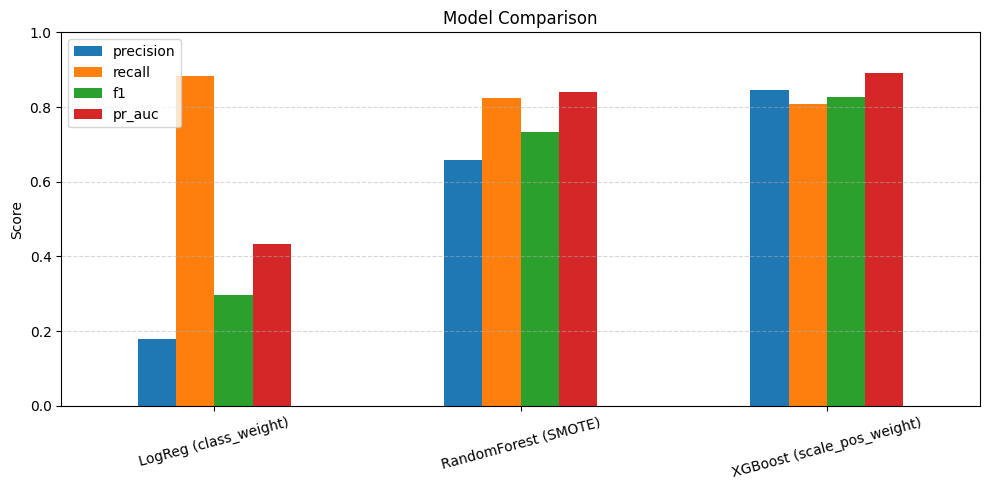

In [30]:
fig, ax = plt.subplots(figsize=(10,5))

scorecard.plot(
    kind='bar',
    ax=ax
)

ax.set_title("Model Comparison")
ax.set_ylabel("Score")
ax.set_ylim(0,1)

plt.xticks(rotation=15)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()

plt.show()

## Observations

* Since only 3.39% of the data represents machine failures, accuracy is not a reliable metric for this problem.
* Precision, Recall, F1 Score, and PR-AUC were used because they better evaluate the model's performance on the minority (failure) class.
* XGBoost achieved the best overall performance with the highest Precision (0.846), F1 Score (0.827), and PR-AUC (0.892) while maintaining a good Recall (0.809).
* Random Forest was the second-best model, showing good performance across all evaluation metrics.
* Logistic Regression achieved the highest Recall (0.882) but had very low Precision (0.178), meaning it detected most failures but also generated many false alarms.

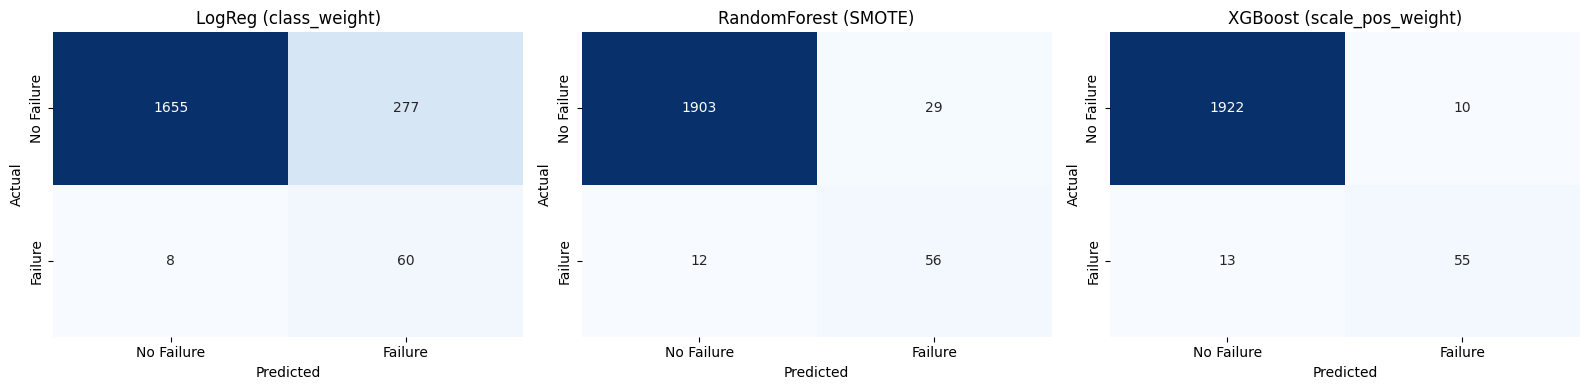

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (name, (pred, _)) in zip(axes, model_objects.items()):

    cm = confusion_matrix(y_test, pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        cbar=False,
        ax=ax,
        xticklabels=['No Failure', 'Failure'],
        yticklabels=['No Failure', 'Failure']
    )

    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

In [32]:
cm_xgb = confusion_matrix(y_test, pred_xgb)

tn, fp, fn, tp = cm_xgb.ravel()

print(f"True Negatives (TN) : {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives (TP) : {tp}")

True Negatives (TN) : 1922
False Positives (FP): 10
False Negatives (FN): 13
True Positives (TP) : 55


### Confusion matrix in business/cost terms (XGBoost)

| Outcome | Count | What it means on the floor | Cost |
|---|---|---|---|
| **False Negative** (missed failure) | 13 | Machine flagged "safe" but actually fails — unplanned downtime, potential safety incident, rush parts/labor | **High** — hours of unplanned downtime, expedited repair, possible collateral damage |
| **False Positive** (false alarm) | 10 | Machine flagged "at risk" but was actually fine — technician sent to inspect for nothing | **Low** — one inspection visit, a few minutes to an hour of technician time |
| **True Positive** (caught failure) | 55 | Correctly flagged — maintenance can schedule a planned intervention before breakdown | Avoided downtime, planned (cheap) maintenance instead of emergency (expensive) repair |
| **True Negative** (correctly healthy) | 1922 | No action needed | — |

* The costs of prediction errors are not equal. A False Negative (missed failure) is much more expensive than a False Positive (false alarm). Missing an actual machine failure can lead to unexpected downtime, emergency repairs, production delays, and safety risks, whereas a False Positive only results in an unnecessary inspection. Therefore, the model is designed to prioritize high recall so that as many actual failures as possible are detected, even if it means performing a few extra inspections. This trade-off helps reduce overall maintenance costs and improves operational reliability.

## 6. Feature Importance — Top Drivers of Failure Risk

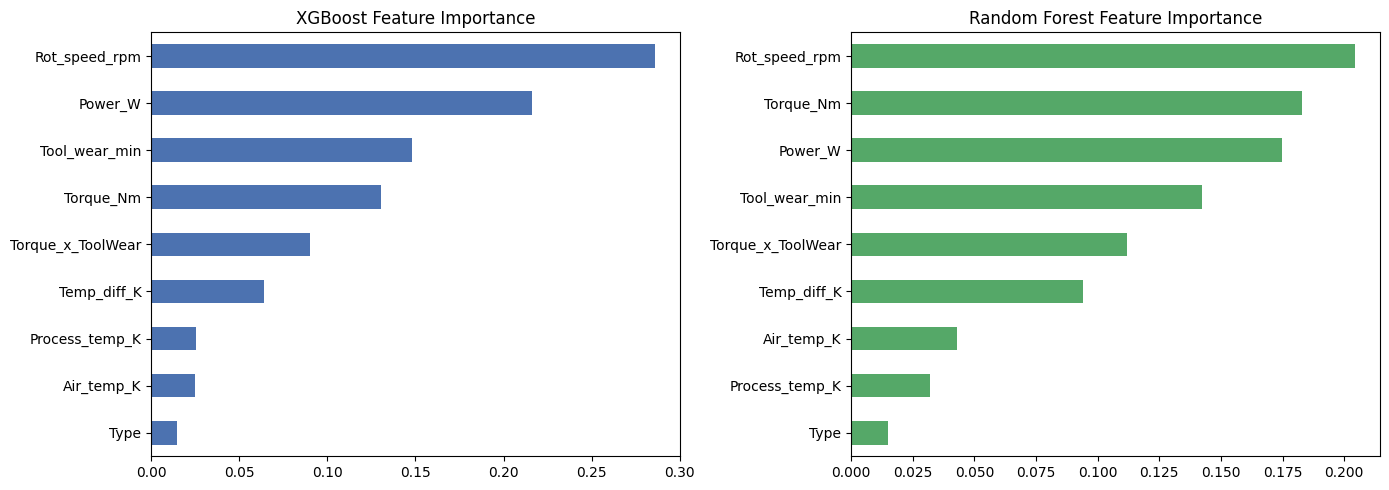

XGBoost top 3: ['Rot_speed_rpm', 'Power_W', 'Tool_wear_min']
Random Forest top 3: ['Rot_speed_rpm', 'Torque_Nm', 'Power_W']


In [34]:
imp_xgb = pd.Series(xgb.feature_importances_, index=feature_cols).sort_values(ascending=False)
imp_rf = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14,5))
imp_xgb.plot(kind='barh', ax=axes[0], color='#4C72B0')
axes[0].invert_yaxis()
axes[0].set_title('XGBoost Feature Importance')

imp_rf.plot(kind='barh', ax=axes[1], color='#55A868')
axes[1].invert_yaxis()
axes[1].set_title('Random Forest Feature Importance')
plt.tight_layout()
plt.show()

print("XGBoost top 3:", list(imp_xgb.head(3).index))
print("Random Forest top 3:", list(imp_rf.head(3).index))


Feature Importance Observations
* Top 3 most important features identified by XGBoost are:

    1.Rotational Speed (rpm)

    2.Power (Torque × Angular Velocity) (engineered feature)
    
    3.Tool Wear (min)
* These results support the Phase 1 hypotheses that mechanical conditions play a major role in machine failures.
* The high importance of the engineered Power feature indicates that the combined effect of rotational speed and torque predicts failures better than using either feature alone.
* Tool Wear is also a key predictor, showing that machines with higher wear are more likely to fail.

## 7. Failure-Mode Breakdown (Stretch: Option B)

Beyond "will it fail," we sketch a simple multi-class model restricted to the rows where a failure occurred, to indicate *which* mode is most likely — this is what tells the maintenance crew which fix to prep. Given the small failure sample (339 rows) and the 24 rows with overlapping modes, we treat this as directional rather than production-grade, and note it as an area for the team to expand with more data.

In [37]:
df.columns

Index(['Type', 'Air_temp_K', 'Process_temp_K', 'Rot_speed_rpm', 'Torque_Nm',
       'Tool_wear_min', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF',
       'Temp_diff_K', 'Power_W', 'Torque_x_ToolWear'],
      dtype='object')

In [39]:
modes = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']

fail_df = df[df['Machine failure'] == 1].copy()

single_mode = fail_df[fail_df[modes].sum(axis=1) == 1].copy()

def get_mode(row):
    for m in modes:
        if row[m] == 1:
            return m

single_mode['Failure_Mode'] = single_mode.apply(get_mode, axis=1)

print(single_mode['Failure_Mode'].value_counts())

Failure_Mode
HDF    106
PWF     80
OSF     78
TWF     42
Name: count, dtype: int64


In [40]:
from sklearn.model_selection import train_test_split

feature_cols = [
    'Type',
    'Air_temp_K',
    'Process_temp_K',
    'Rot_speed_rpm',
    'Torque_Nm',
    'Tool_wear_min',
    'Temp_diff_K',
    'Power_W',
    'Torque_x_ToolWear'
]

X = single_mode[feature_cols]
y = single_mode['Failure_Mode']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [42]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# Encode target
le = LabelEncoder()

y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

xgb_mode = XGBClassifier(
    objective='multi:softprob',
    eval_metric='mlogloss',
    random_state=42,
    n_estimators=300,
    max_depth=4,
    learning_rate=0.1
)

xgb_mode.fit(X_train, y_train_enc)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import lo

In [43]:
pred = xgb_mode.predict(X_test)

In [44]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test_enc,
    pred,
    target_names=le.classes_
))

              precision    recall  f1-score   support

         HDF       0.95      1.00      0.98        21
         OSF       1.00      0.94      0.97        16
         PWF       1.00      1.00      1.00        16
         TWF       1.00      1.00      1.00         9

    accuracy                           0.98        62
   macro avg       0.99      0.98      0.99        62
weighted avg       0.98      0.98      0.98        62



# Maintenance Recommendations

1. Schedule preventive maintenance for machines with high tool wear.
2. Monitor abnormal process–air temperature differences.
3. Trigger inspections when high torque combines with low rotational speed.
4. Deploy real-time alerts using the trained model for early warning.   

